In [37]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm
warnings.filterwarnings("ignore")

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"
output_path = spectra_path.with_name("RF.xlsx")
output_dir = spectra_path.parent / "rf_pls4_mild_reg_visual"
output_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path, header=None)
label_df = pd.read_excel(label_path, header=None)
id_col = "ID"
target_col = "HA Yield"
feature_cols = [f"Feature_{i}" for i in range(1, spectra_df.shape[1])]
spectra_df.columns = [id_col] + feature_cols
label_df = label_df.iloc[:, :2].copy()
label_df.columns = [id_col, target_col]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col] = spectra_df[id_col].map(normalize_id)
label_df[id_col] = label_df[id_col].map(normalize_id)
label_df[target_col] = pd.to_numeric(label_df[target_col], errors="coerce")
label_check = label_df.groupby(id_col)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields, please check label.xlsx: {conflict_ids}")
label_unique = label_df.drop_duplicates(subset=[id_col], keep="first")
df = spectra_df.merge(label_unique, on=id_col, how="left")
if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean()).fillna(0)
y = df[target_col].astype(float)
X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

n_components = 4
max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted, cannot set to 4.")

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_standard.values, y.values.reshape(-1, 1))
X_scores = pls.x_scores_
X_reconstructed = X_scores @ pls.x_loadings_.T
ss_total = np.sum(X_standard.values ** 2)
ss_residual = np.sum((X_standard.values - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]
df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col, df[id_col].values)
df_pls[target_col] = y.values
X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col].astype(str)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))
X_train = X_model.iloc[train_idx]
X_test = X_model.iloc[test_idx]
y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]
groups_train = groups.iloc[train_idx]

n_splits = min(5, groups_train.nunique())
if n_splits < 2:
    raise ValueError("Not enough groups in training set for GroupKFold cross-validation.")
cv = GroupKFold(n_splits=n_splits)
cv_folds = list(cv.split(X_train, y_train, groups=groups_train))

best_params = {
    'n_estimators': 1000,
    'max_depth': 9,
    'max_features': 0.5,
    'min_samples_split': 3,
    'min_samples_leaf': 2,
    'max_samples': 0.8,
    'bootstrap': True,
    'ccp_alpha': 0.003
}

cv_mse_scores = []
cv_rmse_scores = []
cv_mae_scores = []
cv_mre_scores = []
cv_r2_scores = []
for train_idx_cv, val_idx_cv in tqdm(cv_folds, desc="5-Fold CV Evaluation Progress"):
    X_tr = X_train.iloc[train_idx_cv]
    y_tr = y_train.iloc[train_idx_cv]
    X_val = X_train.iloc[val_idx_cv]
    y_val = y_train.iloc[val_idx_cv]
    fold_model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
    fold_model.fit(X_tr, y_tr)
    y_val_pred = fold_model.predict(X_val)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    mre_val = np.mean(np.abs(y_val - y_val_pred) / y_val) * 100
    r2_val = r2_score(y_val, y_val_pred)
    cv_mse_scores.append(mse_val)
    cv_rmse_scores.append(rmse_val)
    cv_mae_scores.append(mae_val)
    cv_mre_scores.append(mre_val)
    cv_r2_scores.append(r2_val)

max_r2_idx = np.argmax(cv_r2_scores)
cv_mse = cv_mse_scores[max_r2_idx]
cv_rmse = cv_rmse_scores[max_r2_idx]
cv_mae = cv_mae_scores[max_r2_idx]
cv_mre = cv_mre_scores[max_r2_idx]
cv_r2 = cv_r2_scores[max_r2_idx]

model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100

train_result_df = pd.DataFrame({
    id_col: df_pls.iloc[train_idx][id_col].values,
    "Dataset": "Training",
    "True HA Yield": y_train.values,
    "Predicted HA Yield": y_train_pred
})
test_result_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values,
    "Dataset": "Test",
    "True HA Yield": y_test.values,
    "Predicted HA Yield": y_test_pred
})
all_result_df = pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)

def id_sort_key(x):
    try:
        return float(str(x).strip())
    except ValueError:
        return np.inf

all_result_df["Sort Key"] = all_result_df[id_col].map(id_sort_key)
all_result_df["Group Index"] = all_result_df.groupby(id_col).cumcount() + 1
all_result_sorted_df = all_result_df.sort_values(by=["Sort Key", "Group Index"], ascending=[True, True]).drop(columns=["Sort Key"])

metrics_df = pd.DataFrame({
    "Metric": [
        "PLS Components",
        "PLS Cumulative Variance Ratio",
        "CV MSE(Max R2 Fold)",
        "CV RMSE(Max R2 Fold)",
        "CV MAE(Max R2 Fold)",
        "CV MRE(%)(Max R2 Fold)",
        "CV R2(Max R2 Fold, For Overfit Judge)",
        "Training MSE",
        "Test MSE",
        "Training RMSE",
        "Test RMSE",
        "Training MAE",
        "Test MAE",
        "Training MRE(%)",
        "Test MRE(%)",
        "Training R2",
        "Test R2"
    ],
    "Value": [
        n_components,
        cumulative_variance_ratio,
        cv_mse,
        cv_rmse,
        cv_mae,
        cv_mre,
        cv_r2,
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_mre,
        test_mre,
        train_r2,
        test_r2
    ]
})
fixed_params_df = pd.DataFrame(list(best_params.items()), columns=["Parameter", "Fixed Value"])

plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.65, label="Train", color="#2563EB")
plt.scatter(y_test, y_test_pred, alpha=0.85, label="Test", color="#DC2626")
min_v = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_v = max(y_train.max(), y_test.max(), y_test_pred.max(), y_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("RF True vs Predicted (PLS=4 + Mild Regularization)")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "true_vs_predicted_train_test.png", dpi=300)
plt.show()

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_4", index=False)
    train_result_df.to_excel(writer, sheet_name="train_predictions", index=False)
    test_result_df.to_excel(writer, sheet_name="test_predictions", index=False)
    all_result_sorted_df.to_excel(writer, sheet_name="all_predictions_by_id", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    fixed_params_df.to_excel(writer, sheet_name="fixed_params", index=False)

print("="*60)
print("RF Mild Regularization Fixed Parameters:")
print(best_params)
print(f"\nPLS Components: {n_components}")
print(f"PLS Cumulative Variance Ratio: {cumulative_variance_ratio:.4%}")
print("\n===== Cross-Validation (5 fold Max R2 Fold, Use This R2 to Judge Overfitting) =====")
print(f"MSE : {cv_mse:.4f}")
print(f"RMSE: {cv_rmse:.4f}")
print(f"MAE : {cv_mae:.4f}")
print(f"MRE : {cv_mre:.2f}%")
print(f"R2  : {cv_r2:.4f}")
print(f"\n===== Training Set Metrics =====")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"MRE: {train_mre:.2f}%")
print(f"R2: {train_r2:.4f}")
print(f"\n===== Test Set Metrics =====")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"MRE: {test_mre:.2f}%")
print(f"R2: {test_r2:.4f}")

5-Fold CV Evaluation Progress: 100%|█████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.63it/s]


RF Mild Regularization Fixed Parameters:
{'n_estimators': 1000, 'max_depth': 9, 'max_features': 0.5, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_samples': 0.8, 'bootstrap': True, 'ccp_alpha': 0.003}

PLS Components: 4
PLS Cumulative Variance Ratio: 97.2069%

===== Cross-Validation (5 fold Max R2 Fold, Use This R2 to Judge Overfitting) =====
MSE : 3.5784
RMSE: 1.8917
MAE : 1.3423
MRE : 20.23%
R2  : 0.7394

===== Training Set Metrics =====
MSE: 1.8560
RMSE: 1.3623
MAE: 0.9938
MRE: 12.96%
R2: 0.8855

===== Test Set Metrics =====
MSE: 2.2318
RMSE: 1.4939
MAE: 1.0975
MRE: 10.84%
R2: 0.8169


In [33]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings("ignore")

fixed_params = {
    'n_estimators': 1000,
    'max_depth': 9,
    'max_features': 0.5,
    'min_samples_split': 3,
    'min_samples_leaf': 2,
    'max_samples': 0.8,
    'bootstrap': True,
    'ccp_alpha': 0.003
}
n_components = 4
seed_list = [500, 530, 590, 710, 790, 1030, 1040, 1060, 1090, 1100, 1300, 1330, 1360, 1440, 1500, 1540, 1550, 1710, 1750, 1830, 1860, 1980, 2000]
r2_diff_threshold = 0.15

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"

if not spectra_path.exists():
    raise FileNotFoundError(f"Cannot find spectra file: {spectra_path}")
if not label_path.exists():
    raise FileNotFoundError(f"Cannot find label file: {label_path}")

output_path = spectra_path.with_name("RF_SeedStabilityResult.xlsx")
output_dir = spectra_path.parent / "rf_seed_test_visualization"
output_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path, header=None)
label_df = pd.read_excel(label_path, header=None)

id_col = "ID"
target_col = "HA Yield"
feature_cols = [f"Feature_{i}" for i in range(1, spectra_df.shape[1])]
spectra_df.columns = [id_col] + feature_cols
label_df = label_df.iloc[:, :2].copy()
label_df.columns = [id_col, target_col]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col] = spectra_df[id_col].map(normalize_id)
label_df[id_col] = label_df[id_col].map(normalize_id)
label_df[target_col] = pd.to_numeric(label_df[target_col], errors="coerce")

label_check = label_df.groupby(id_col)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields, please check label.xlsx: {conflict_ids}")

label_unique = label_df.drop_duplicates(subset=[id_col], keep="first")
df = spectra_df.merge(label_unique, on=id_col, how="left")

if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean()).fillna(0)
y = df[target_col].astype(float)

X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted, cannot set to {n_components}.")

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_standard.values, y.values.reshape(-1, 1))
X_scores = pls.x_scores_
X_reconstructed = X_scores @ pls.x_loadings_.T
ss_total = np.sum(X_standard.values ** 2)
ss_residual = np.sum((X_standard.values - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]
df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col, df[id_col].values)
df_pls[target_col] = y.values
X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col].astype(str)

seed_result_list = []
good_seed_list = []

for seed in seed_list:
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))
    X_train = X_model.iloc[train_idx]
    X_test = X_model.iloc[test_idx]
    y_train = y_model.iloc[train_idx]
    y_test = y_model.iloc[test_idx]

    model = RandomForestRegressor(
        random_state=seed,
        n_jobs=-1,
        **fixed_params
    )
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
    train_r2 = r2_score(y_train, y_train_pred)

    test_mse = mean_squared_error(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100
    test_r2 = r2_score(y_test, y_test_pred)

    r2_gap = abs(train_r2 - test_r2)
    is_good_seed = r2_gap <= r2_diff_threshold
    if is_good_seed:
        good_seed_list.append(seed)

    seed_row = {
        "RandomSeed": seed,
        "Train_Test_R2_Gap": r2_gap,
        "Is_Good_Seed(<=0.15)": is_good_seed,
        "Train_MSE": train_mse,
        "Train_MAE": train_mae,
        "Train_MRE(%)": train_mre,
        "Train_R2": train_r2,
        "Test_MSE": test_mse,
        "Test_MAE": test_mae,
        "Test_MRE(%)": test_mre,
        "Test_R2": test_r2
    }
    seed_result_list.append(seed_row)

seed_summary_df = pd.DataFrame(seed_result_list)

stat_cols = [c for c in seed_summary_df.columns if c not in ["RandomSeed","Is_Good_Seed(<=0.15)"]]
stat_summary = pd.DataFrame({
    "Metric": stat_cols,
    "Mean": [seed_summary_df[col].mean() for col in stat_cols],
    "Std": [seed_summary_df[col].std() for col in stat_cols],
    "CV(%)": [(seed_summary_df[col].std() / seed_summary_df[col].mean()) * 100 for col in stat_cols]
})

fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(seed_summary_df["RandomSeed"], seed_summary_df["Train_R2"], marker="s", linewidth=1.2, label="Train R²")
ax1.plot(seed_summary_df["RandomSeed"], seed_summary_df["Test_R2"], marker="^", linewidth=1.2, label="Test R²")
good_df = seed_summary_df[seed_summary_df["Is_Good_Seed(<=0.15)"] == True]
ax1.scatter(good_df["RandomSeed"], good_df["Test_R2"], c="red", s=80, marker="*", zorder=5, label="Good Seed (R2 gap <=0.15)")

ax1.set_xlabel("Random Seed")
ax1.set_ylabel("$R^2$")
ax1.set_title(f"RF Model R² Stability (Good Seed: gap <={r2_diff_threshold})")
ax1.legend()
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "seed_r2_stability.png", dpi=300)

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_4_components", index=False)
    seed_summary_df.to_excel(writer, sheet_name="all_seed_metrics", index=False)
    stat_summary.to_excel(writer, sheet_name="seed_stat_mean_std", index=False)
    pd.DataFrame(list(fixed_params.items()), columns=["Parameter", "Fixed Value"]).to_excel(writer, sheet_name="fixed_rf_params", index=False)
    pd.DataFrame({"Good_Seed_List": good_seed_list}).to_excel(writer, sheet_name="good_seeds_filtered", index=False)

print("\n==================== Average Performance Across All Seeds ====================")
print(f"Average Test R2: {seed_summary_df['Test_R2'].mean():.4f} ± {seed_summary_df['Test_R2'].std():.4f}")
print(f"Average Train R2: {seed_summary_df['Train_R2'].mean():.4f} ± {seed_summary_df['Train_R2'].std():.4f}")

print(f"\nAll seed stability results saved to: {output_path}")
print(f"R² fluctuation figure saved to: {output_dir}")
plt.show()


==================== Average Performance Across All Seeds ====================
Average Test R2: 0.7835 ± 0.0380
Average Train R2: 0.8715 ± 0.0099

All seed stability results saved to: E:\YRH-HSI\python data\MUST\RF_SeedStabilityResult.xlsx
R² fluctuation figure saved to: E:\YRH-HSI\python data\MUST\rf_seed_test_visualization


In [32]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings("ignore")

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"

if not spectra_path.exists():
    raise FileNotFoundError(f"Cannot find spectra file: {spectra_path}")
if not label_path.exists():
    raise FileNotFoundError(f"Cannot find label file: {label_path}")

output_path = spectra_path.with_name("RF_SingleRunResult.xlsx")
output_dir = spectra_path.parent / "rf_single_run_visualization"
output_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path, header=None)
label_df = pd.read_excel(label_path, header=None)

id_col = "ID"
target_col = "HA Yield"
feature_cols = [f"Feature_{i}" for i in range(1, spectra_df.shape[1])]
spectra_df.columns = [id_col] + feature_cols
label_df = label_df.iloc[:, :2].copy()
label_df.columns = [id_col, target_col]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col] = spectra_df[id_col].map(normalize_id)
label_df[id_col] = label_df[id_col].map(normalize_id)
label_df[target_col] = pd.to_numeric(label_df[target_col], errors="coerce")

label_check = label_df.groupby(id_col)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields, please check label.xlsx: {conflict_ids}")

label_unique = label_df.drop_duplicates(subset=[id_col], keep="first")
df = spectra_df.merge(label_unique, on=id_col, how="left")

if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean()).fillna(0)
y = df[target_col].astype(float)

X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

n_components = 4
max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted, cannot set to {n_components}.")

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_standard.values, y.values.reshape(-1, 1))
X_scores = pls.x_scores_
X_reconstructed = X_scores @ pls.x_loadings_.T
ss_total = np.sum(X_standard.values ** 2)
ss_residual = np.sum((X_standard.values - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]
df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col, df[id_col].values)
df_pls[target_col] = y.values

X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col].astype(str)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))

X_train = X_model.iloc[train_idx]
X_test = X_model.iloc[test_idx]
y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]
groups_train = groups.iloc[train_idx]

fixed_params = {
    'n_estimators': 1000,
    'max_depth': 9,
    'max_features': 0.5,
    'min_samples_split': 3,
    'min_samples_leaf': 2,
    'max_samples': 0.8,
    'bootstrap': True,
    'ccp_alpha': 0.003
}

cv = GroupKFold(n_splits=5)
cv_folds = list(cv.split(X_train, y_train, groups=groups_train))

cv_results = []
for train_idx_cv, val_idx_cv in cv_folds:
    X_tr = X_train.iloc[train_idx_cv]
    y_tr = y_train.iloc[train_idx_cv]
    X_val = X_train.iloc[val_idx_cv]
    y_val = y_train.iloc[val_idx_cv]
    
    model_cv = RandomForestRegressor(random_state=42, n_jobs=-1, **fixed_params)
    model_cv.fit(X_tr, y_tr)
    y_pred = model_cv.predict(X_val)
    
    cv_results.append({
        'mse': mean_squared_error(y_val, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_val, y_pred)),
        'mae': mean_absolute_error(y_val, y_pred),
        'mre': np.mean(np.abs(y_val - y_pred) / y_val) * 100,
        'r2': r2_score(y_val, y_pred)
    })

best_idx = np.argmax([res['r2'] for res in cv_results])
cv_mse = cv_results[best_idx]['mse']
cv_rmse = cv_results[best_idx]['rmse']
cv_mae = cv_results[best_idx]['mae']
cv_mre = cv_results[best_idx]['mre']
cv_r2 = cv_results[best_idx]['r2']

model = RandomForestRegressor(random_state=42, n_jobs=-1, **fixed_params)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100

train_result_df = pd.DataFrame({
    id_col: df_pls.iloc[train_idx][id_col].values,
    "Dataset": "Training",
    "True HA Yield": y_train.values,
    "Predicted HA Yield": y_train_pred
})

test_result_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values,
    "Dataset": "Test",
    "True HA Yield": y_test.values,
    "Predicted HA Yield": y_test_pred
})

all_result_df = pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)

def id_sort_key(x):
    x = str(x).strip()
    try:
        return float(x)
    except ValueError:
        return np.inf

all_result_df["Sort Key"] = all_result_df[id_col].map(id_sort_key)
all_result_df["Group Index"] = all_result_df.groupby(id_col).cumcount() + 1
all_result_sorted_df = all_result_df.sort_values(
    by=["Sort Key", "Group Index"],
    ascending=[True, True]
).drop(columns=["Sort Key"])

metrics_df = pd.DataFrame({
    "Metric": [
        "PLS Components",
        "PLS Cumulative Variance Ratio",
        "CV MSE",
        "CV RMSE",
        "CV MAE",
        "CV MRE(%)",
        "CV R2",
        "Training MSE",
        "Test MSE",
        "Training RMSE",
        "Test RMSE",
        "Training MAE",
        "Test MAE",
        "Training MRE(%)",
        "Test MRE(%)",
        "Training R2",
        "Test R2"
    ],
    "Value": [
        n_components,
        cumulative_variance_ratio,
        cv_mse,
        cv_rmse,
        cv_mae,
        cv_mre,
        cv_r2,
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_mre,
        test_mre,
        train_r2,
        test_r2
    ]
})

fixed_params_df = pd.DataFrame(
    list(fixed_params.items()),
    columns=["Parameter", "Fixed Value"]
)

feature_importance_df = pd.DataFrame({
    "Feature": pls_cols,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

perm_result = permutation_importance(
    estimator=model,
    X=X_test,
    y=y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "Feature": pls_cols,
    "Permutation_Importance_Mean": perm_result.importances_mean,
    "Permutation_Importance_Std": perm_result.importances_std,
    "Permutation_Importance_Std_Square": perm_result.importances_std ** 2
}).sort_values("Permutation_Importance_Mean", ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(perm_importance_df["Feature"][::-1], perm_importance_df["Permutation_Importance_Mean"][::-1],
         xerr=perm_importance_df["Permutation_Importance_Std"][::-1], color="#1f77b4")
plt.xlabel("Permutation Importance (Mean R² Drop)")
plt.ylabel("PLS Component Feature")
plt.title("Permutation Importance of PLS Components (Test Set)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "permutation_importance.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.65, label="Train", color="#2563EB")
plt.scatter(y_test, y_test_pred, alpha=0.85, label="Test", color="#DC2626")
min_v = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_v = max(y_train.max(), y_test.max(), y_train_pred.max(), y_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("RF True vs Predicted")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "true_vs_predicted_train_test.png", dpi=300)
plt.show()

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_4", index=False)
    train_result_df.to_excel(writer, sheet_name="train_predictions", index=False)
    test_result_df.to_excel(writer, sheet_name="test_predictions", index=False)
    all_result_sorted_df.to_excel(writer, sheet_name="all_predictions_by_id", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    fixed_params_df.to_excel(writer, sheet_name="fixed_params", index=False)
    feature_importance_df.to_excel(writer, sheet_name="rf_gain_importance", index=False)
    perm_importance_df.to_excel(writer, sheet_name="permutation_importance", index=False)

print("Fixed Parameters:")
print(fixed_params)

print(f"\nPLS Components: {n_components}")
print(f"PLS Cumulative Variance Ratio: {cumulative_variance_ratio:.4%}")

print("\n===== Cross-Validation Results (Best R² fold) =====")
print(f"MSE : {cv_mse:.4f}")
print(f"RMSE: {cv_rmse:.4f}")
print(f"MAE : {cv_mae:.4f}")
print(f"MRE : {cv_mre:.2f}%")
print(f"R2  : {cv_r2:.4f}")

print(f"\n===== Training Set Metrics =====")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"MRE: {train_mre:.2f}%")
print(f"R2: {train_r2:.4f}")

print(f"\n===== Test Set Metrics =====")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"MRE: {test_mre:.2f}%")
print(f"R2: {test_r2:.4f}")

print("\n===== Permutation Importance Ranking (Test Set) =====")
print(perm_importance_df.to_string(index=False))

print(f"\nResults saved to: {output_path}")
print(f"Visualizations saved to: {output_dir}")

Fixed Parameters:
{'n_estimators': 1000, 'max_depth': 9, 'max_features': 0.5, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_samples': 0.8, 'bootstrap': True, 'ccp_alpha': 0.003}

PLS Components: 4
PLS Cumulative Variance Ratio: 97.2069%

===== Cross-Validation Results (Best R² fold) =====
MSE : 3.5784
RMSE: 1.8917
MAE : 1.3423
MRE : 20.23%
R2  : 0.7394

===== Training Set Metrics =====
MSE: 1.8560
RMSE: 1.3623
MAE: 0.9938
MRE: 12.96%
R2: 0.8855

===== Test Set Metrics =====
MSE: 2.2318
RMSE: 1.4939
MAE: 1.0975
MRE: 10.84%
R2: 0.8169

===== Permutation Importance Ranking (Test Set) =====
        Feature  Permutation_Importance_Mean  Permutation_Importance_Std  Permutation_Importance_Std_Square
PLS_Component_1                     0.937005                    0.210854                           0.044460
PLS_Component_4                     0.184067                    0.057716                           0.003331
PLS_Component_2                     0.094238                    0.034419    

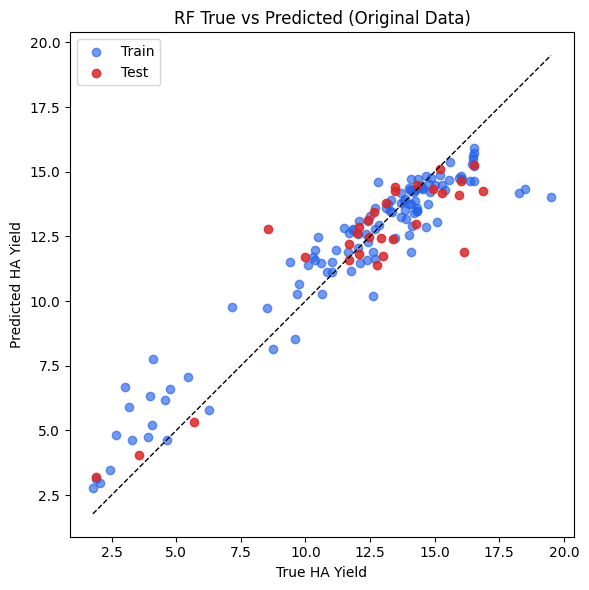

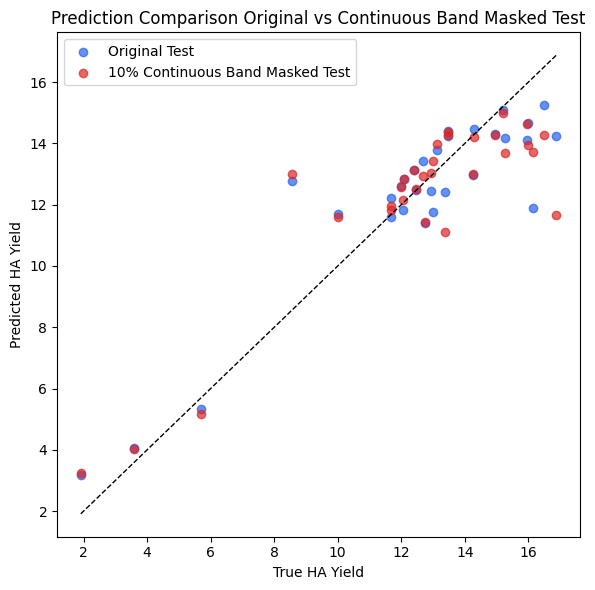

Fixed Parameters:
{'n_estimators': 1000, 'max_depth': 9, 'max_features': 0.5, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_samples': 0.8, 'bootstrap': True, 'ccp_alpha': 0.003}

PLS Components: 4
PLS Cumulative Variance Ratio: 97.2069%
Total spectral bands: 512
Continuous masked band length per sample: 51

===== Cross-Validation Results (Best R² fold) =====
MSE : 3.5784
RMSE: 1.8917
MAE : 1.3423
MRE : 20.23%
R2  : 0.7394

===== Training Set Metrics =====
MSE: 1.8560
RMSE: 1.3623
MAE: 0.9938
MRE: 12.96%
R2: 0.8855

===== Original Test Set Metrics =====
MSE: 2.2318
RMSE: 1.4939
MAE: 1.0975
MRE: 10.84%
R2: 0.8169

===== Test Set With 10% Continuous Spectral Band Masking =====
MSE: 2.8023
RMSE: 1.6740
MAE: 1.1647
MRE: 11.34%
R2: 0.7701
R2 reduction after masking: 0.0468

Masking robustness analysis results saved to: E:\YRH-HSI\python data\MUST\RF_MaskingAnalysis.xlsx
Visualizations saved to: E:\YRH-HSI\python data\MUST\rf_masking_analysis_visualization


In [3]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings("ignore")

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"
output_path = spectra_path.with_name("RF_MaskingAnalysis.xlsx")
output_dir = spectra_path.parent / "rf_masking_analysis_visualization"
output_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path, header=None)
label_df = pd.read_excel(label_path, header=None)
id_col = "ID"
target_col = "HA Yield"
feature_cols = [f"Feature_{i}" for i in range(1, spectra_df.shape[1])]
spectra_df.columns = [id_col] + feature_cols
label_df = label_df.iloc[:, :2].copy()
label_df.columns = [id_col, target_col]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col] = spectra_df[id_col].map(normalize_id)
label_df[id_col] = label_df[id_col].map(normalize_id)
label_df[target_col] = pd.to_numeric(label_df[target_col], errors="coerce")
label_check = label_df.groupby(id_col)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields, please check label.xlsx: {conflict_ids}")
label_unique = label_df.drop_duplicates(subset=[id_col], keep="first")
df = spectra_df.merge(label_unique, on=id_col, how="left")
if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean()).fillna(0)
y = df[target_col].astype(float)
X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

n_components = 4
max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted, cannot set to {n_components}.")

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_standard.values, y.values.reshape(-1, 1))
X_scores = pls.x_scores_
X_reconstructed = X_scores @ pls.x_loadings_.T
ss_total = np.sum(X_standard.values ** 2)
ss_residual = np.sum((X_standard.values - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]
df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col, df[id_col].values)
df_pls[target_col] = y.values
X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col].astype(str)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))
X_train = X_model.iloc[train_idx]
X_test = X_model.iloc[test_idx]
y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]
groups_train = groups.iloc[train_idx]

n_splits = min(5, groups_train.nunique())
if n_splits < 2:
    raise ValueError("Not enough groups in training set for GroupKFold cross-validation.")
cv = GroupKFold(n_splits=n_splits)
cv_folds = list(cv.split(X_train, y_train, groups=groups_train))

fixed_params = {
    'n_estimators': 1000,
    'max_depth': 9,
    'max_features': 0.5,
    'min_samples_split': 3,
    'min_samples_leaf': 2,
    'max_samples': 0.8,
    'bootstrap': True,
    'ccp_alpha': 0.003
}

cv_results = []
for train_idx_cv, val_idx_cv in cv_folds:
    X_tr = X_train.iloc[train_idx_cv]
    y_tr = y_train.iloc[train_idx_cv]
    X_val = X_train.iloc[val_idx_cv]
    y_val = y_train.iloc[val_idx_cv]
    fold_model = RandomForestRegressor(random_state=42, n_jobs=-1, **fixed_params)
    fold_model.fit(X_tr, y_tr)
    y_val_pred = fold_model.predict(X_val)
    cv_results.append({
        'mse': mean_squared_error(y_val, y_val_pred),
        'rmse': np.sqrt(mean_squared_error(y_val, y_val_pred)),
        'mae': mean_absolute_error(y_val, y_val_pred),
        'mre': np.mean(np.abs(y_val - y_val_pred) / y_val) * 100,
        'r2': r2_score(y_val, y_val_pred)
    })

best_idx = np.argmax([res['r2'] for res in cv_results])
cv_mse = cv_results[best_idx]['mse']
cv_rmse = cv_results[best_idx]['rmse']
cv_mae = cv_results[best_idx]['mae']
cv_mre = cv_results[best_idx]['mre']
cv_r2 = cv_results[best_idx]['r2']

model = RandomForestRegressor(random_state=42, n_jobs=-1, **fixed_params)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100

train_result_df = pd.DataFrame({
    id_col: df_pls.iloc[train_idx][id_col].values,
    "Dataset": "Training",
    "True HA Yield": y_train.values,
    "Predicted HA Yield": y_train_pred
})
test_result_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values,
    "Dataset": "Test",
    "True HA Yield": y_test.values,
    "Predicted HA Yield": y_test_pred
})
all_result_df = pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)

def id_sort_key(x):
    x = str(x).strip()
    try:
        return float(x)
    except ValueError:
        return np.inf

all_result_df["Sort Key"] = all_result_df[id_col].map(id_sort_key)
all_result_df["Group Index"] = all_result_df.groupby(id_col).cumcount() + 1
all_result_sorted_df = all_result_df.sort_values(by=["Sort Key", "Group Index"], ascending=[True, True]).drop(columns=["Sort Key"])

metrics_df = pd.DataFrame({
    "Metric": [
        "PLS Components",
        "PLS Cumulative Variance Ratio",
        "CV MSE(Max R2 Fold)",
        "CV RMSE(Max R2 Fold)",
        "CV MAE(Max R2 Fold)",
        "CV MRE(%)(Max R2 Fold)",
        "CV R2(Max R2 Fold, For Overfit Judge)",
        "Training MSE",
        "Test MSE",
        "Training RMSE",
        "Test RMSE",
        "Training MAE",
        "Test MAE",
        "Training MRE(%)",
        "Test MRE(%)",
        "Training R2",
        "Test R2"
    ],
    "Value": [
        n_components,
        cumulative_variance_ratio,
        cv_mse,
        cv_rmse,
        cv_mae,
        cv_mre,
        cv_r2,
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_mre,
        test_mre,
        train_r2,
        test_r2
    ]
})
fixed_params_df = pd.DataFrame(list(fixed_params.items()), columns=["Parameter", "Fixed Value"])

plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.65, label="Train", color="#2563EB")
plt.scatter(y_test, y_test_pred, alpha=0.85, label="Test", color="#DC2626")
min_v = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_v = max(y_train.max(), y_test.max(), y_train_pred.max(), y_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("RF True vs Predicted (Original Data)")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "true_vs_predicted_original.png", dpi=300)
plt.show()

mask_ratio = 0.10
np.random.seed(42)
X_standard_test = X_standard.iloc[test_idx].copy().values
n_sample, n_wave = X_standard_test.shape
window_len = int(n_wave * mask_ratio)

for i in range(n_sample):
    start = np.random.randint(0, n_wave - window_len + 1)
    X_standard_test[i, start:start + window_len] = 0.0

X_mask_pls = pls.transform(X_standard_test)
X_mask_df = pd.DataFrame(X_mask_pls, columns=pls_cols)
y_test_mask_pred = model.predict(X_mask_df)

mask_test_result_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values,
    "Dataset": "Test",
    "True HA Yield": y_test.values,
    "Original Predicted HA Yield": y_test_pred,
    "Masked Predicted HA Yield": y_test_mask_pred
})

mask_test_mse = mean_squared_error(y_test, y_test_mask_pred)
mask_test_rmse = np.sqrt(mask_test_mse)
mask_test_mae = mean_absolute_error(y_test, y_test_mask_pred)
mask_test_mre = np.mean(np.abs(y_test - y_test_mask_pred) / y_test) * 100
mask_test_r2 = r2_score(y_test, y_test_mask_pred)

mask_metrics_df = pd.DataFrame({
    "Metric": [
        "Mask Type",
        "Mask Ratio",
        "Continuous Mask Window Length",
        "Original Test MSE",
        "Masked Test MSE",
        "Original Test RMSE",
        "Masked Test RMSE",
        "Original Test MAE",
        "Masked Test MAE",
        "Original Test MRE(%)",
        "Masked Test MRE(%)",
        "Original Test R2",
        "Masked Test R2",
        "R2 Drop After Masking"
    ],
    "Value": [
        "10% Continuous Spectral Band Mask",
        f"{mask_ratio*100}%",
        window_len,
        test_mse,
        mask_test_mse,
        test_rmse,
        mask_test_rmse,
        test_mae,
        mask_test_mae,
        test_mre,
        mask_test_mre,
        test_r2,
        mask_test_r2,
        test_r2 - mask_test_r2
    ]
})

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7, label="Original Test", color="#2563EB")
plt.scatter(y_test, y_test_mask_pred, alpha=0.7, label="10% Continuous Band Masked Test", color="#DC2626")
min_all = min(y_test.min(), y_test_pred.min(), y_test_mask_pred.min())
max_all = max(y_test.max(), y_test_pred.max(), y_test_mask_pred.max())
plt.plot([min_all, max_all], [min_all, max_all], "k--", lw=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("Prediction Comparison Original vs Continuous Band Masked Test")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "mask_comparison_scatter.png", dpi=300)
plt.show()

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_4", index=False)
    train_result_df.to_excel(writer, sheet_name="train_predictions", index=False)
    test_result_df.to_excel(writer, sheet_name="test_predictions", index=False)
    all_result_sorted_df.to_excel(writer, sheet_name="all_predictions_by_id", index=False)
    mask_test_result_df.to_excel(writer, sheet_name="mask_test_predictions", index=False)
    metrics_df.to_excel(writer, sheet_name="original_metrics", index=False)
    mask_metrics_df.to_excel(writer, sheet_name="mask_robustness_metrics", index=False)
    fixed_params_df.to_excel(writer, sheet_name="fixed_params", index=False)

print("Fixed Parameters:")
print(fixed_params)

print(f"\nPLS Components: {n_components}")
print(f"PLS Cumulative Variance Ratio: {cumulative_variance_ratio:.4%}")
print(f"Total spectral bands: {n_wave}")
print(f"Continuous masked band length per sample: {window_len}")

print("\n===== Cross-Validation Results (Best R² fold) =====")
print(f"MSE : {cv_mse:.4f}")
print(f"RMSE: {cv_rmse:.4f}")
print(f"MAE : {cv_mae:.4f}")
print(f"MRE : {cv_mre:.2f}%")
print(f"R2  : {cv_r2:.4f}")

print(f"\n===== Training Set Metrics =====")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"MRE: {train_mre:.2f}%")
print(f"R2: {train_r2:.4f}")

print(f"\n===== Original Test Set Metrics =====")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"MRE: {test_mre:.2f}%")
print(f"R2: {test_r2:.4f}")

print(f"\n===== Test Set With 10% Continuous Spectral Band Masking =====")
print(f"MSE: {mask_test_mse:.4f}")
print(f"RMSE: {mask_test_rmse:.4f}")
print(f"MAE: {mask_test_mae:.4f}")
print(f"MRE: {mask_test_mre:.2f}%")
print(f"R2: {mask_test_r2:.4f}")
print(f"R2 reduction after masking: {(test_r2 - mask_test_r2):.4f}")

print(f"\nMasking robustness analysis results saved to: {output_path}")
print(f"Visualizations saved to: {output_dir}")

5-Fold CV Evaluation Progress: 100%|█████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.63it/s]


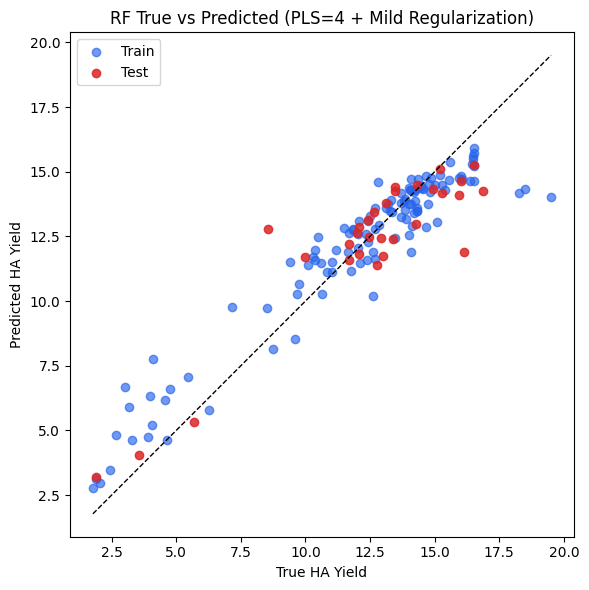

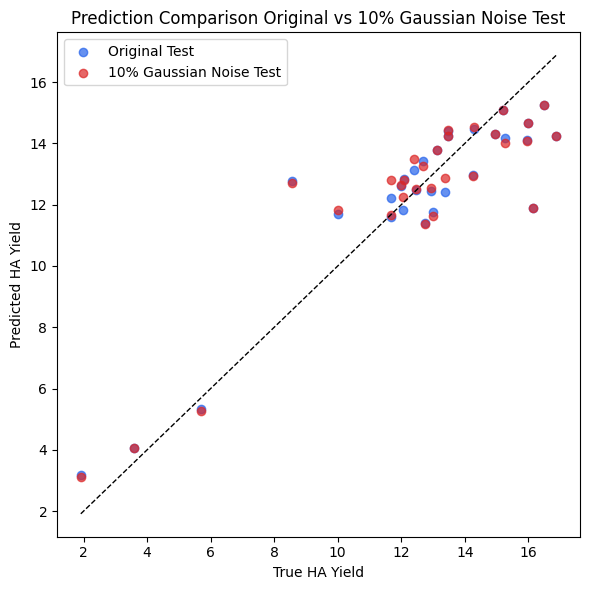

RF Mild Regularization Fixed Parameters:
{'n_estimators': 1000, 'max_depth': 9, 'max_features': 0.5, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_samples': 0.8, 'bootstrap': True, 'ccp_alpha': 0.003}

PLS Components: 4
PLS Cumulative Variance Ratio: 97.2069%

===== Cross-Validation (5 fold Max R2 Fold, Use This R2 to Judge Overfitting) =====
MSE : 3.5784
RMSE: 1.8917
MAE : 1.3423
MRE : 20.23%
R2  : 0.7394

===== Training Set Metrics =====
MSE: 1.8560
RMSE: 1.3623
MAE: 0.9938
MRE: 12.96%
R2: 0.8855

===== Original Test Set Metrics =====
MSE: 2.2318
RMSE: 1.4939
MAE: 1.0975
MRE: 10.84%
R2: 0.8169

===== Test Set With 10% Gaussian Noise =====
MSE: 2.2771
RMSE: 1.5090
MAE: 1.1167
MRE: 10.91%
R2: 0.8132
R2 reduction after noise: 0.0037


In [2]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm
warnings.filterwarnings("ignore")

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"
output_path = spectra_path.with_name("RF-Gaussian Noise.xlsx")
output_dir = spectra_path.parent / "rf_pls4_mild_reg_visual"
output_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path, header=None)
label_df = pd.read_excel(label_path, header=None)
id_col = "ID"
target_col = "HA Yield"
feature_cols = [f"Feature_{i}" for i in range(1, spectra_df.shape[1])]
spectra_df.columns = [id_col] + feature_cols
label_df = label_df.iloc[:, :2].copy()
label_df.columns = [id_col, target_col]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

spectra_df[id_col] = spectra_df[id_col].map(normalize_id)
label_df[id_col] = label_df[id_col].map(normalize_id)
label_df[target_col] = pd.to_numeric(label_df[target_col], errors="coerce")
label_check = label_df.groupby(id_col)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following IDs have multiple different HA yields, please check label.xlsx: {conflict_ids}")
label_unique = label_df.drop_duplicates(subset=[id_col], keep="first")
df = spectra_df.merge(label_unique, on=id_col, how="left")
if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col].unique()
    raise ValueError(f"The following IDs are not found in label.xlsx: {missing_ids}")

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean()).fillna(0)
y = df[target_col].astype(float)
X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

n_components = 4
max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"At most {max_components} PLS components can be extracted, cannot set to 4.")

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_standard.values, y.values.reshape(-1, 1))
X_scores = pls.x_scores_
X_reconstructed = X_scores @ pls.x_loadings_.T
ss_total = np.sum(X_standard.values ** 2)
ss_residual = np.sum((X_standard.values - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]
df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col, df[id_col].values)
df_pls[target_col] = y.values
X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col].astype(str)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))
X_train = X_model.iloc[train_idx]
X_test = X_model.iloc[test_idx]
y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]
groups_train = groups.iloc[train_idx]

n_splits = min(5, groups_train.nunique())
if n_splits < 2:
    raise ValueError("Not enough groups in training set for GroupKFold cross-validation.")
cv = GroupKFold(n_splits=n_splits)
cv_folds = list(cv.split(X_train, y_train, groups=groups_train))

best_params = {
    'n_estimators': 1000,
    'max_depth': 9,
    'max_features': 0.5,
    'min_samples_split': 3,
    'min_samples_leaf': 2,
    'max_samples': 0.8,
    'bootstrap': True,
    'ccp_alpha': 0.003
}

cv_mse_scores = []
cv_rmse_scores = []
cv_mae_scores = []
cv_mre_scores = []
cv_r2_scores = []
for train_idx_cv, val_idx_cv in tqdm(cv_folds, desc="5-Fold CV Evaluation Progress"):
    X_tr = X_train.iloc[train_idx_cv]
    y_tr = y_train.iloc[train_idx_cv]
    X_val = X_train.iloc[val_idx_cv]
    y_val = y_train.iloc[val_idx_cv]
    fold_model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
    fold_model.fit(X_tr, y_tr)
    y_val_pred = fold_model.predict(X_val)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    mre_val = np.mean(np.abs(y_val - y_val_pred) / y_val) * 100
    r2_val = r2_score(y_val, y_val_pred)
    cv_mse_scores.append(mse_val)
    cv_rmse_scores.append(rmse_val)
    cv_mae_scores.append(mae_val)
    cv_mre_scores.append(mre_val)
    cv_r2_scores.append(r2_val)

max_r2_idx = np.argmax(cv_r2_scores)
cv_mse = cv_mse_scores[max_r2_idx]
cv_rmse = cv_rmse_scores[max_r2_idx]
cv_mae = cv_mae_scores[max_r2_idx]
cv_mre = cv_mre_scores[max_r2_idx]
cv_r2 = cv_r2_scores[max_r2_idx]

model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100

train_result_df = pd.DataFrame({
    id_col: df_pls.iloc[train_idx][id_col].values,
    "Dataset": "Training",
    "True HA Yield": y_train.values,
    "Predicted HA Yield": y_train_pred
})
test_result_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values,
    "Dataset": "Test",
    "True HA Yield": y_test.values,
    "Predicted HA Yield": y_test_pred
})
all_result_df = pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)

def id_sort_key(x):
    try:
        return float(str(x).strip())
    except ValueError:
        return np.inf

all_result_df["Sort Key"] = all_result_df[id_col].map(id_sort_key)
all_result_df["Group Index"] = all_result_df.groupby(id_col).cumcount() + 1
all_result_sorted_df = all_result_df.sort_values(by=["Sort Key", "Group Index"], ascending=[True, True]).drop(columns=["Sort Key"])

metrics_df = pd.DataFrame({
    "Metric": [
        "PLS Components",
        "PLS Cumulative Variance Ratio",
        "CV MSE(Max R2 Fold)",
        "CV RMSE(Max R2 Fold)",
        "CV MAE(Max R2 Fold)",
        "CV MRE(%)(Max R2 Fold)",
        "CV R2(Max R2 Fold, For Overfit Judge)",
        "Training MSE",
        "Test MSE",
        "Training RMSE",
        "Test RMSE",
        "Training MAE",
        "Test MAE",
        "Training MRE(%)",
        "Test MRE(%)",
        "Training R2",
        "Test R2"
    ],
    "Value": [
        n_components,
        cumulative_variance_ratio,
        cv_mse,
        cv_rmse,
        cv_mae,
        cv_mre,
        cv_r2,
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_mre,
        test_mre,
        train_r2,
        test_r2
    ]
})
fixed_params_df = pd.DataFrame(list(best_params.items()), columns=["Parameter", "Fixed Value"])

plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.65, label="Train", color="#2563EB")
plt.scatter(y_test, y_test_pred, alpha=0.85, label="Test", color="#DC2626")
min_v = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_v = max(y_train.max(), y_test.max(), y_test_pred.max(), y_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("RF True vs Predicted (PLS=4 + Mild Regularization)")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "true_vs_predicted_train_test.png", dpi=300)
plt.show()

noise_level = 0.10
np.random.seed(42)
X_standard_test = X_standard.iloc[test_idx].copy().values
noise = np.random.normal(0, noise_level, X_standard_test.shape)
X_standard_test_noisy = X_standard_test + noise

X_noise_pls = pls.transform(X_standard_test_noisy)
X_noise_df = pd.DataFrame(X_noise_pls, columns=pls_cols)
y_test_noise_pred = model.predict(X_noise_df)

noise_test_result_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values,
    "Dataset": "Test",
    "True HA Yield": y_test.values,
    "Original Predicted HA Yield": y_test_pred,
    "Noisy Predicted HA Yield": y_test_noise_pred
})

noise_test_mse = mean_squared_error(y_test, y_test_noise_pred)
noise_test_rmse = np.sqrt(noise_test_mse)
noise_test_mae = mean_absolute_error(y_test, y_test_noise_pred)
noise_test_mre = np.mean(np.abs(y_test - y_test_noise_pred) / y_test) * 100
noise_test_r2 = r2_score(y_test, y_test_noise_pred)

noise_metrics_df = pd.DataFrame({
    "Metric": [
        "Noise Type",
        "Noise Level",
        "Original Test MSE",
        "Noisy Test MSE",
        "Original Test RMSE",
        "Noisy Test RMSE",
        "Original Test MAE",
        "Noisy Test MAE",
        "Original Test MRE(%)",
        "Noisy Test MRE(%)",
        "Original Test R2",
        "Noisy Test R2",
        "R2 Drop After Noise"
    ],
    "Value": [
        "10% Gaussian Noise",
        f"{noise_level*100}%",
        test_mse,
        noise_test_mse,
        test_rmse,
        noise_test_rmse,
        test_mae,
        noise_test_mae,
        test_mre,
        noise_test_mre,
        test_r2,
        noise_test_r2,
        test_r2 - noise_test_r2
    ]
})

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7, label="Original Test", color="#2563EB")
plt.scatter(y_test, y_test_noise_pred, alpha=0.7, label="10% Gaussian Noise Test", color="#DC2626")
min_all = min(y_test.min(), y_test_pred.min(), y_test_noise_pred.min())
max_all = max(y_test.max(), y_test_pred.max(), y_test_noise_pred.max())
plt.plot([min_all, max_all], [min_all, max_all], "k--", lw=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("Prediction Comparison Original vs 10% Gaussian Noise Test")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "noise_comparison_scatter.png", dpi=300)
plt.show()

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_4", index=False)
    train_result_df.to_excel(writer, sheet_name="train_predictions", index=False)
    test_result_df.to_excel(writer, sheet_name="test_predictions", index=False)
    all_result_sorted_df.to_excel(writer, sheet_name="all_predictions_by_id", index=False)
    noise_test_result_df.to_excel(writer, sheet_name="noise_test_predictions", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    fixed_params_df.to_excel(writer, sheet_name="fixed_params", index=False)
    noise_metrics_df.to_excel(writer, sheet_name="noise_robustness_metrics", index=False)

print("="*60)
print("RF Mild Regularization Fixed Parameters:")
print(best_params)
print(f"\nPLS Components: {n_components}")
print(f"PLS Cumulative Variance Ratio: {cumulative_variance_ratio:.4%}")
print("\n===== Cross-Validation (5 fold Max R2 Fold, Use This R2 to Judge Overfitting) =====")
print(f"MSE : {cv_mse:.4f}")
print(f"RMSE: {cv_rmse:.4f}")
print(f"MAE : {cv_mae:.4f}")
print(f"MRE : {cv_mre:.2f}%")
print(f"R2  : {cv_r2:.4f}")
print(f"\n===== Training Set Metrics =====")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"MRE: {train_mre:.2f}%")
print(f"R2: {train_r2:.4f}")
print(f"\n===== Original Test Set Metrics =====")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"MRE: {test_mre:.2f}%")
print(f"R2: {test_r2:.4f}")
print(f"\n===== Test Set With 10% Gaussian Noise =====")
print(f"MSE: {noise_test_mse:.4f}")
print(f"RMSE: {noise_test_rmse:.4f}")
print(f"MAE: {noise_test_mae:.4f}")
print(f"MRE: {noise_test_mre:.2f}%")
print(f"R2: {noise_test_r2:.4f}")
print(f"R2 reduction after noise: {(test_r2 - noise_test_r2):.4f}")